In [46]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report

In [47]:
file_path = "../data/processed/unsw_nb15_processed.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)

Dataset shape: (175341, 45)


In [48]:
X = df.drop(["id","label", "attack_cat"], axis=1)
y = df["label"]

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [50]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [51]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.98      0.81      0.88     11169
           1       0.92      0.99      0.95     23900

    accuracy                           0.93     35069
   macro avg       0.95      0.90      0.92     35069
weighted avg       0.94      0.93      0.93     35069



In [52]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
print("SVM Results:")
print(classification_report(y_test, y_pred_svm))

SVM Results:
              precision    recall  f1-score   support

           0       0.99      0.79      0.88     11169
           1       0.91      1.00      0.95     23900

    accuracy                           0.93     35069
   macro avg       0.95      0.89      0.92     35069
weighted avg       0.94      0.93      0.93     35069



In [53]:
import joblib

rf_model = joblib.load("../models/random_forest_model.pkl")

ValueError: EOF: reading array data, expected 262080 bytes got 127808

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

svm_scores = svm_model.decision_function(X_test_scaled)

svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_scores)

svm_auc = roc_auc_score(y_test, svm_scores)

print("SVM AUC:", svm_auc)

SVM AUC: 0.9757316987282868


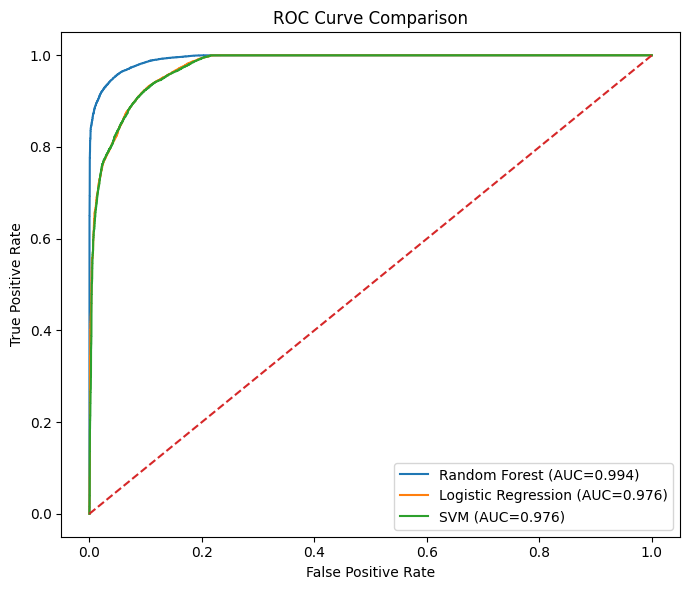

In [ ]:
rf_probs = rf_model.predict_proba(X_test)[:, 1]
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]
svm_scores = svm_model.decision_function(X_test_scaled)

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_scores)

rf_auc = roc_auc_score(y_test, rf_probs)
log_auc = roc_auc_score(y_test, log_probs)
svm_auc = roc_auc_score(y_test, svm_scores)

plt.figure(figsize=(7,6))
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC={rf_auc:.3f})")
plt.plot(log_fpr, log_tpr, label=f"Logistic Regression (AUC={log_auc:.3f})")
plt.plot(svm_fpr, svm_tpr, label=f"SVM (AUC={svm_auc:.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("../results/figures/roc_comparison.png", dpi=300)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

rf_pred = rf_model.predict(X_test)
log_pred = log_model.predict(X_test_scaled)
svm_pred = svm_model.predict(X_test_scaled)

results = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression", "SVM"],
    
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, svm_pred)
    ],
    
    "Precision": [
        precision_score(y_test, rf_pred),
        precision_score(y_test, log_pred),
        precision_score(y_test, svm_pred)
    ],
    
    "Recall": [
        recall_score(y_test, rf_pred),
        recall_score(y_test, log_pred),
        recall_score(y_test, svm_pred)
    ],
    
    "F1 Score": [
        f1_score(y_test, rf_pred),
        f1_score(y_test, log_pred),
        f1_score(y_test, svm_pred)
    ],
    
    "ROC-AUC": [rf_auc, log_auc, svm_auc]
})

results.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.958026,0.956857,0.982720,0.969616,0.993702
1,Logistic Regression,0.932276,0.916006,0.991548,0.952281,0.976403
2,SVM,0.931335,0.910748,0.996946,0.951900,0.975732


In [ ]:
results.to_csv("../results/tables/model_comparison.csv", index=False)

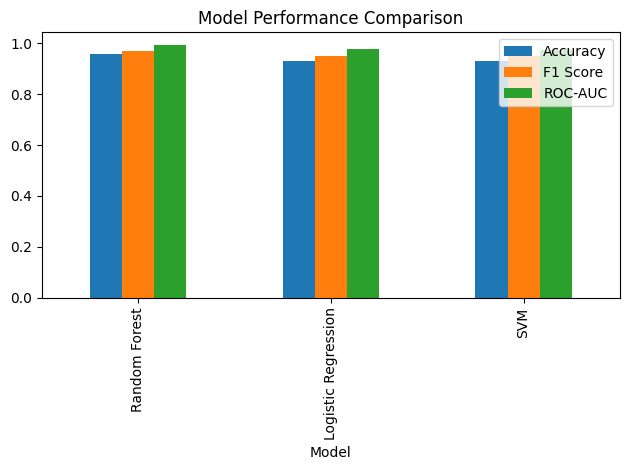

In [ ]:
import matplotlib.pyplot as plt

results.set_index("Model")[["Accuracy","F1 Score","ROC-AUC"]].plot(kind="bar")

plt.title("Model Performance Comparison")

plt.tight_layout()

plt.savefig("../results/figures/model_comparison.png", dpi=300)

plt.show()